In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("ball_by_ball_ipl.csv")
df

,Unnamed: 0,Match ID,Date,Venue,Bat First,Bat Second,Innings,Over,Ball,Batter,...,Winner,Chased Successfully,Total Batter Runs,Total Non Striker Runs,Batter Balls Faced,Non Striker Balls Faced,Player Out Runs,Player Out Balls Faced,Bowler Runs Conceded,Valid Ball
0,0,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,1,RD Gaikwad,...,Chennai Super Kings,0,4,0,1,0,NaN,NaN,4,1
1,1,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,2,RD Gaikwad,...,Chennai Super Kings,0,4,0,2,0,NaN,NaN,0,1
2,2,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,3,RD Gaikwad,...,Chennai Super Kings,0,4,0,3,0,NaN,NaN,0,1
3,3,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,4,RD Gaikwad,...,Chennai Super Kings,0,4,0,4,0,NaN,NaN,0,1
4,4,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,5,RD Gaikwad,...,Chennai Super Kings,0,5,0,5,0,NaN,NaN,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239688,239688,1136596,2018-05-05,Rajiv Gandhi International Stadium,Delhi Daredevils,Sunrisers Hyderabad,2,20,1,YK Pathan,...,Sunrisers Hyderabad,1,16,31,9,29,NaN,NaN,2,1
239689,239689,1136596,2018-05-05,Rajiv Gandhi International Stadium,Delhi Daredevils,Sunrisers Hyderabad,2,20,2,YK Pathan,...,Sunrisers Hyderabad,1,22,31,10,29,NaN,NaN,6,1
239690,239690,1136596,2018-05-05,Rajiv Gandhi International Stadium,Delhi Daredevils,Sunrisers Hyderabad,2,20,3,YK Pathan,...,Sunrisers Hyderabad,1,26,31,11,29,NaN,NaN,4,1
239691,239691,1136596,2018-05-05,Rajiv Gandhi International Stadium,Delhi Daredevils,Sunrisers Hyderabad,2,20,4,YK Pathan,...,Sunrisers Hyderabad,1,27,31,12,29,NaN,NaN,1,1


In [4]:
df['Cumulative Runs'] = df.groupby(['Match ID','Batter'])['Batter Runs'].cumsum()
df

,Unnamed: 0,Match ID,Date,Venue,Bat First,Bat Second,Innings,Over,Ball,Batter,...,Chased Successfully,Total Batter Runs,Total Non Striker Runs,Batter Balls Faced,Non Striker Balls Faced,Player Out Runs,Player Out Balls Faced,Bowler Runs Conceded,Valid Ball,Cumulative Runs
0,0,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,1,RD Gaikwad,...,0,4,0,1,0,NaN,NaN,4,1,4
1,1,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,2,RD Gaikwad,...,0,4,0,2,0,NaN,NaN,0,1,4
2,2,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,3,RD Gaikwad,...,0,4,0,3,0,NaN,NaN,0,1,4
3,3,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,4,RD Gaikwad,...,0,4,0,4,0,NaN,NaN,0,1,4
4,4,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,5,RD Gaikwad,...,0,5,0,5,0,NaN,NaN,1,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239688,239688,1136596,2018-05-05,Rajiv Gandhi International Stadium,Delhi Daredevils,Sunrisers Hyderabad,2,20,1,YK Pathan,...,1,16,31,9,29,NaN,NaN,2,1,16
239689,239689,1136596,2018-05-05,Rajiv Gandhi International Stadium,Delhi Daredevils,Sunrisers Hyderabad,2,20,2,YK Pathan,...,1,22,31,10,29,NaN,NaN,6,1,22
239690,239690,1136596,2018-05-05,Rajiv Gandhi International Stadium,Delhi Daredevils,Sunrisers Hyderabad,2,20,3,YK Pathan,...,1,26,31,11,29,NaN,NaN,4,1,26
239691,239691,1136596,2018-05-05,Rajiv Gandhi International Stadium,Delhi Daredevils,Sunrisers Hyderabad,2,20,4,YK Pathan,...,1,27,31,12,29,NaN,NaN,1,1,27


In [11]:
df['year'] = pd.to_datetime(df['Date']).dt.year

In [12]:
 # Step 1: Calculate cumulative runs and balls faced for each batter in each match
df['Cumulative Runs'] = df.groupby(['Match ID', 'Batter'])['Batter Runs'].cumsum()
df['Balls Faced'] = df.groupby(['Match ID', 'Batter']).cumcount() + 1

# Step 2: Filter instances where the batter reaches 50 runs
fifties = df[df['Cumulative Runs'] >= 50]

# Step 3: Get the fastest fifty for each year using idxmin()
fastest_fifties = fifties.loc[fifties.groupby('year')['Balls Faced'].idxmin(),
                              ['year', 'Batter', 'Balls Faced']]

# Step 4: Rename columns and prepare for visualization
fastest_fifties.columns = ['year', 'Player', 'Balls Taken for Fifty']
fastest_fifties['year'] = fastest_fifties['year'].astype(str)

In [13]:
# Group the data by venue and count unique Match IDs
venue_match_counts = (
    df.groupby('Venue')['Match ID'].nunique()       
      .reset_index()                                
      .rename(columns={'Match ID': 'Total Matches'}) 
      .sort_values('Total Matches', ascending=False)
)

C:\Users\Sameer kampa\AppData\Local\Temp\ipykernel_12996\628144746.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=venue_match_counts.head(10),


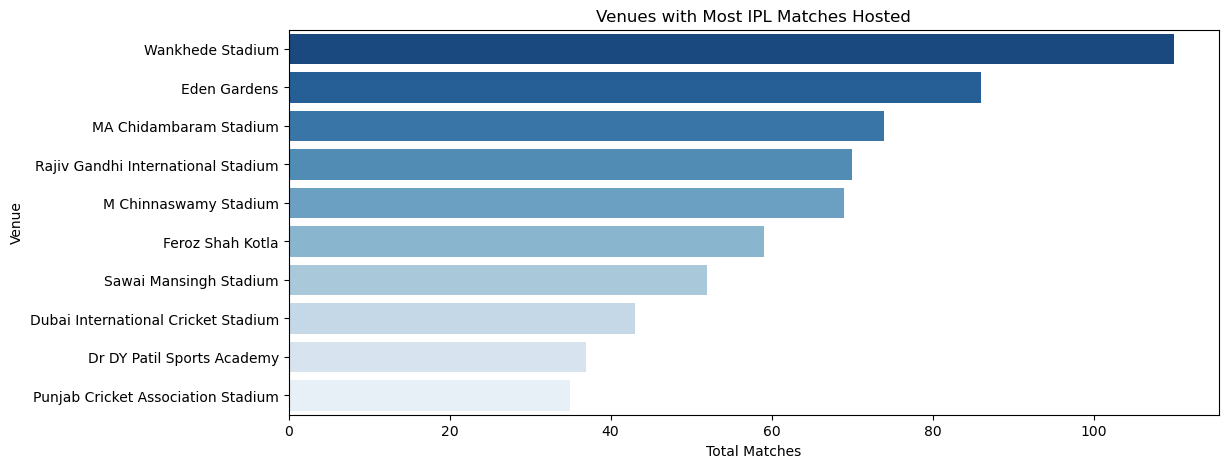

In [14]:
# Plot the top 10 venues with most matches hosted
plt.figure(figsize=(12, 5))
sns.barplot(data=venue_match_counts.head(10), 
            x='Total Matches', y='Venue', 
            palette='Blues_r')

plt.title("Venues with Most IPL Matches Hosted")
plt.xlabel("Total Matches")
plt.ylabel("Venue")
plt.show()